# Spotify Tracks Clustering Analysis

This notebook covers:
1. Data preprocessing
2. Exploratory visualization
3. K-Means clustering
4. Hierarchical clustering
5. Cluster interpretation

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Dataset

In [2]:
# Try the filename from the prompt first, then fallback to the available file.
candidate_files = ['spotify+tracks.csv', 'spotify-tracks.csv']

df = None
selected_file = None
for f in candidate_files:
    try:
        df = pd.read_csv(f)
        selected_file = f
        break
    except FileNotFoundError:
        pass

if df is None:
    raise FileNotFoundError('Neither spotify+tracks.csv nor spotify-tracks.csv was found.')

print(f'Loaded file: {selected_file}')
print('Shape:', df.shape)
df.head()

Loaded file: spotify-tracks.csv
Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 3. Preprocessing

In [3]:
# Remove an index-like first column if present.
first_col = df.columns[0]
if str(first_col).lower().startswith('unnamed') or first_col == '':
    df = df.drop(columns=[first_col])

print('Columns after cleanup:', len(df.columns))
print(df.columns.tolist())

Columns after cleanup: 20
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [4]:
print(df.info())
print('\nMissing values by column:')
print(df.isnull().sum().sort_values(ascending=False).head(15))

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [5]:
# Handle duplicates using track_id where possible.
before = len(df)
if 'track_id' in df.columns:
    df = df.drop_duplicates(subset=['track_id'])
else:
    df = df.drop_duplicates()

after = len(df)
print(f'Rows before dedup: {before}')
print(f'Rows after dedup : {after}')
print(f'Removed          : {before - after}')

Rows before dedup: 114000
Rows after dedup : 89741
Removed          : 24259


In [6]:
# Convert explicit to numeric if needed.
if 'explicit' in df.columns:
    if df['explicit'].dtype == bool:
        df['explicit'] = df['explicit'].astype(int)
    else:
        df['explicit'] = df['explicit'].astype(str).str.lower().map({'true': 1, 'false': 0}).fillna(0).astype(int)

# Select features for clustering (music/audio + popularity/time).
candidate_features = [
    'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key',
    'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature'
]

features = [c for c in candidate_features if c in df.columns]
X = df[features].copy()

# Fill numeric missing values with median.
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median(numeric_only=True))

print('Selected feature count:', len(features))
print('Features:', features)
print('Modeling matrix shape:', X.shape)

Selected feature count: 15
Features: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Modeling matrix shape: (89741, 15)


## 4. Exploratory Visualization

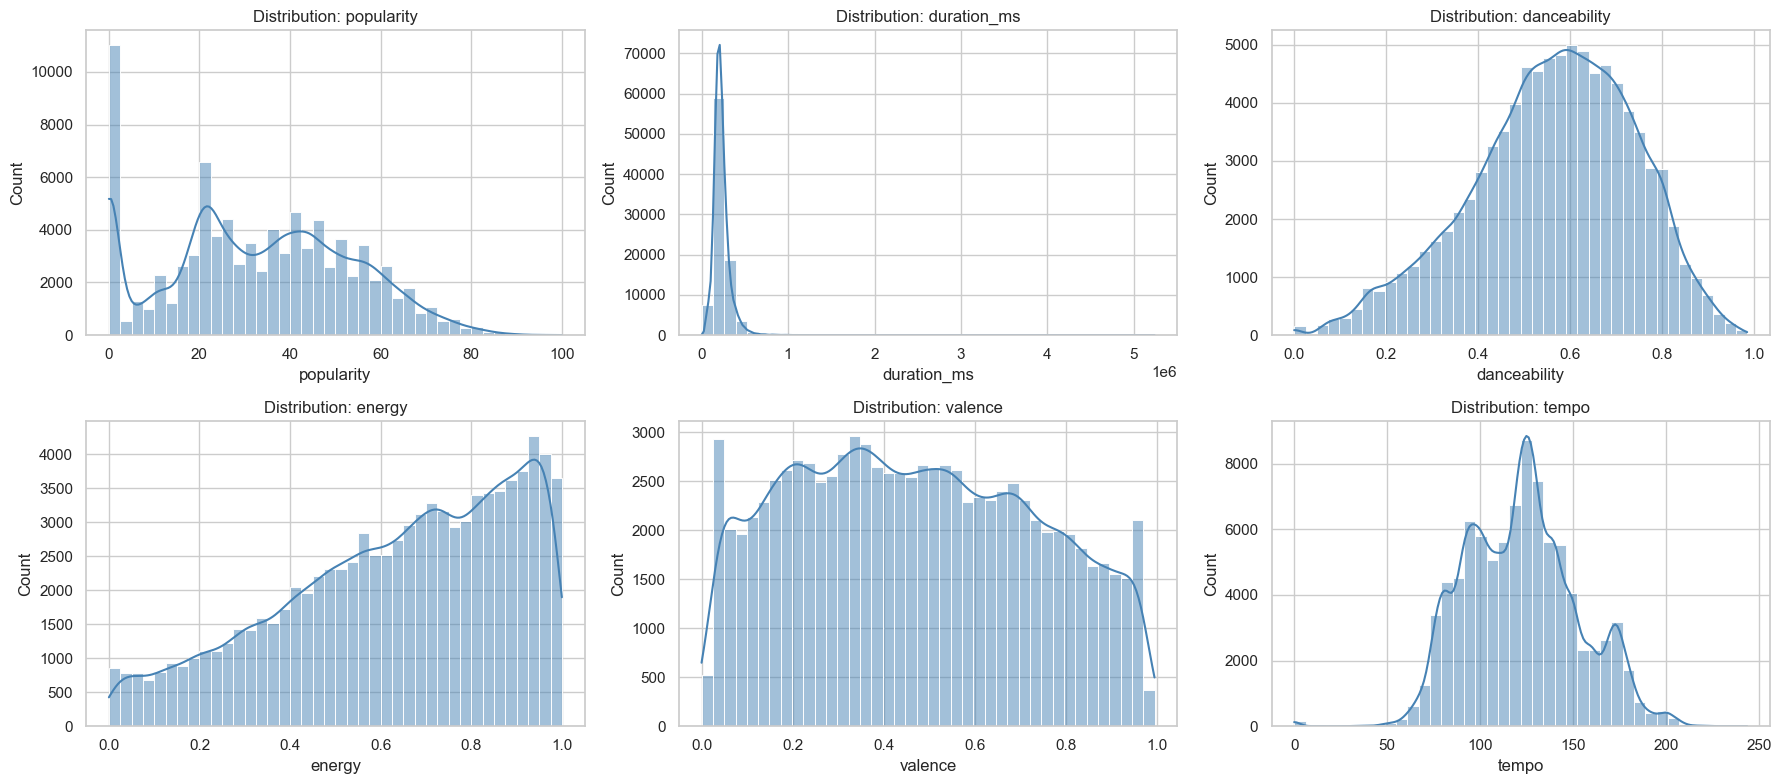

In [7]:
# Distribution plots for key numeric features.
plot_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 'valence', 'tempo']
plot_cols = [c for c in plot_cols if c in X.columns]

n = len(plot_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(plot_cols):
    sns.histplot(X[c], bins=40, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {c}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

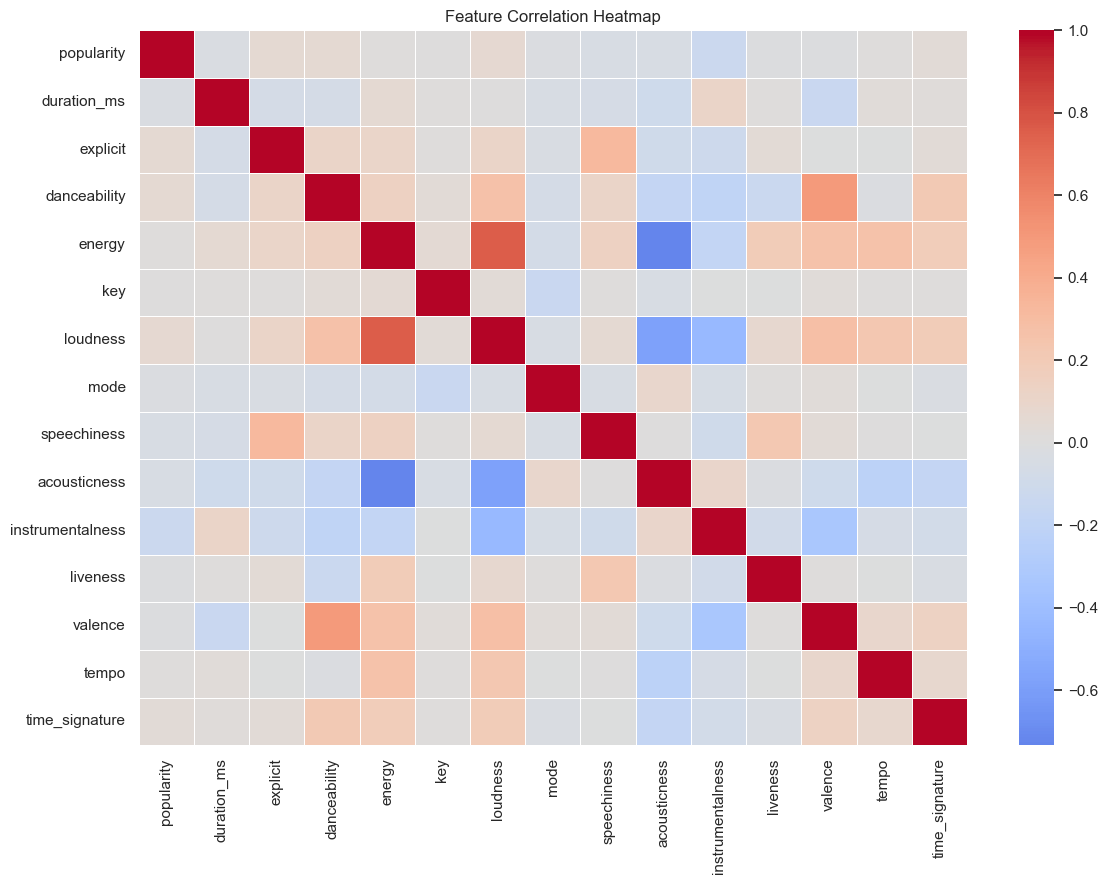

In [8]:
# Correlation heatmap.
corr = X.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

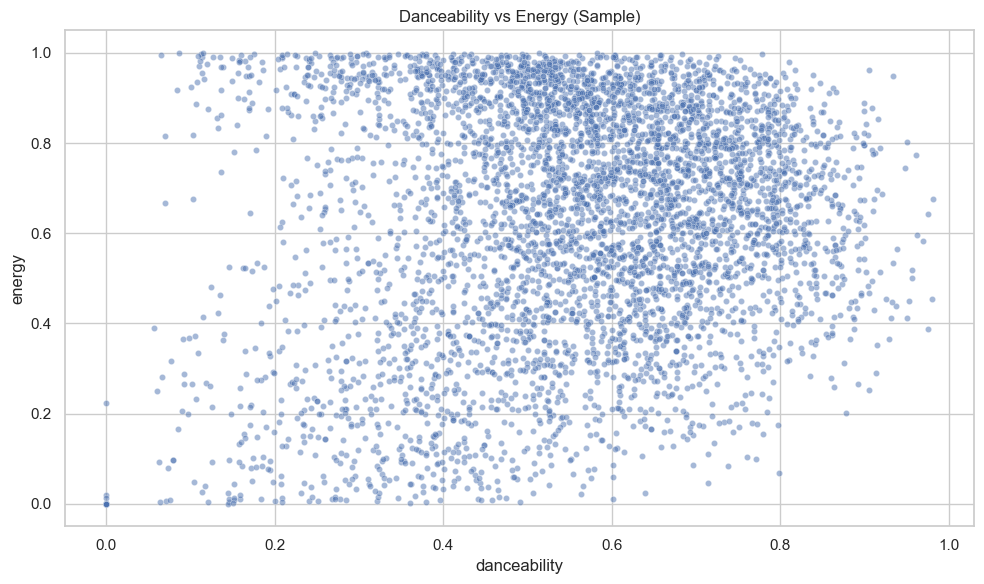

In [9]:
# Quick scatter for common audio dimensions.
if {'danceability', 'energy'}.issubset(X.columns):
    sample_vis = df.sample(min(5000, len(df)), random_state=42).copy()
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sample_vis, x='danceability', y='energy', alpha=0.5, s=20)
    plt.title('Danceability vs Energy (Sample)')
    plt.tight_layout()
    plt.show()
else:
    print('danceability/energy columns not available for scatter plot.')

## 5. Feature Scaling

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled matrix shape:', X_scaled.shape)
print('Scaled feature means (approx):', np.round(X_scaled.mean(axis=0), 4))

Scaled matrix shape: (89741, 15)
Scaled feature means (approx): [ 0.  0. -0. -0.  0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.]


## 6. K-Means Clustering

In [11]:
# Use a manageable subset for tuning k to keep runtime reasonable.
tune_n = min(20000, len(X))
tune_idx = np.random.RandomState(42).choice(len(X), size=tune_n, replace=False)
X_tune = X_scaled[tune_idx]

ks = list(range(2, 11))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_tune)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_tune, labels))

best_k = ks[int(np.argmax(silhouettes))]
print('Best k by silhouette:', best_k)
print('Silhouette scores:', dict(zip(ks, np.round(silhouettes, 4))))

Best k by silhouette: 3
Silhouette scores: {2: np.float64(0.1844), 3: np.float64(0.1972), 4: np.float64(0.1072), 5: np.float64(0.1043), 6: np.float64(0.1113), 7: np.float64(0.1204), 8: np.float64(0.1212), 9: np.float64(0.112), 10: np.float64(0.1191)}


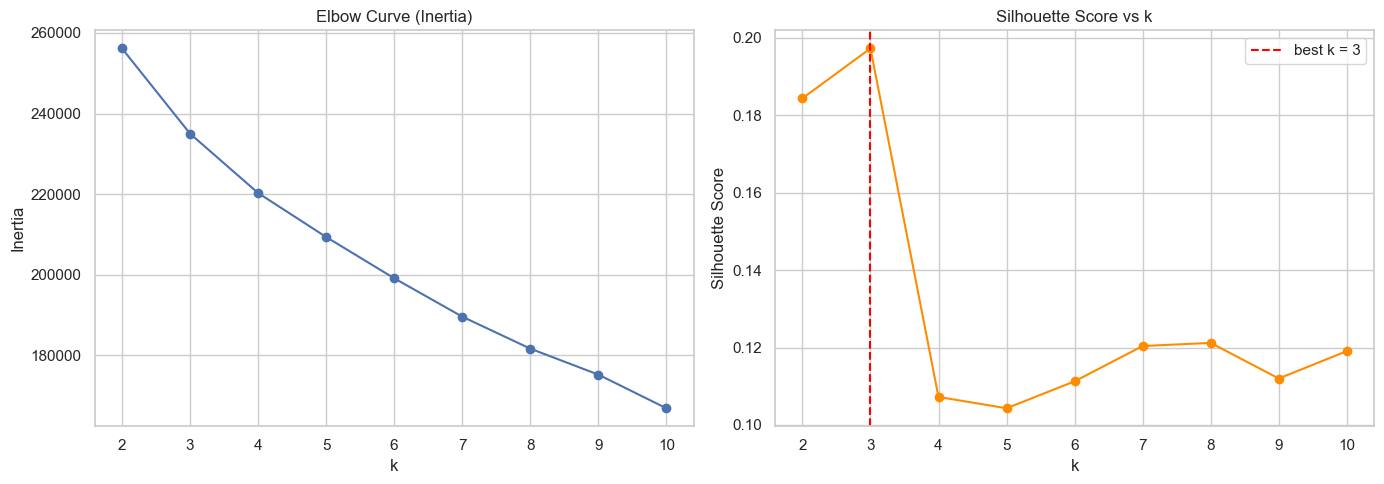

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(ks, inertias, marker='o')
ax[0].set_title('Elbow Curve (Inertia)')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')

ax[1].plot(ks, silhouettes, marker='o', color='darkorange')
ax[1].set_title('Silhouette Score vs k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette Score')
ax[1].axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
ax[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Final K-Means on full scaled data.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['kmeans_cluster'] = kmeans_labels

kmeans_silhouette = silhouette_score(X_tune, KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_tune))
print('K-Means final k:', best_k)
print('K-Means silhouette (tuning subset):', round(kmeans_silhouette, 4))
print('Cluster counts:')
print(df_clustered['kmeans_cluster'].value_counts().sort_index())

K-Means final k: 3
K-Means silhouette (tuning subset): 0.1972
Cluster counts:
kmeans_cluster
0     8023
1    60630
2    21088
Name: count, dtype: int64


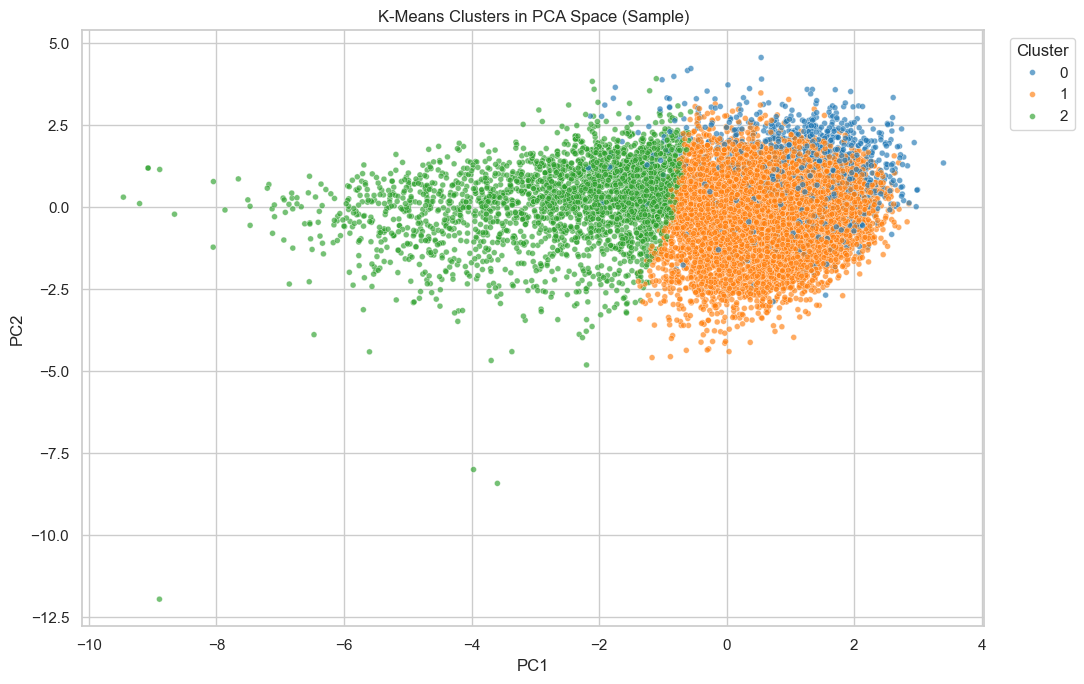

PCA explained variance (PC1+PC2): 0.3048


In [14]:
# PCA projection for visualization.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

vis_n = min(12000, len(df_clustered))
vis_idx = np.random.RandomState(42).choice(len(df_clustered), size=vis_n, replace=False)

plt.figure(figsize=(11, 7))
sns.scatterplot(x=X_pca[vis_idx, 0], y=X_pca[vis_idx, 1],
                hue=df_clustered.iloc[vis_idx]['kmeans_cluster'],
                palette='tab10', s=18, alpha=0.65, legend='full')
plt.title('K-Means Clusters in PCA Space (Sample)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

explained = pca.explained_variance_ratio_.sum()
print('PCA explained variance (PC1+PC2):', round(explained, 4))

In [15]:
# K-Means cluster profile (feature means).
kmeans_profile = df_clustered.groupby('kmeans_cluster')[features].mean().round(3)
kmeans_profile

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
kmeans_cluster,,,,,,,,,,,,,,,
0,36.360,204161.929,0.957,0.629,0.719,5.351,-6.823,0.587,0.238,0.247,0.052,0.262,0.467,121.031,3.939
1,33.945,236654.766,0.000,0.592,0.744,5.391,-6.544,0.620,0.079,0.189,0.132,0.224,0.527,126.565,3.962
2,29.849,217045.037,0.001,0.451,0.289,4.950,-14.756,0.704,0.054,0.761,0.339,0.180,0.304,109.491,3.695


## 7. Hierarchical Clustering

In [16]:
# Hierarchical clustering is expensive on large datasets, so use a sample.
h_n = min(3000, len(X))
h_idx = np.random.RandomState(42).choice(len(X), size=h_n, replace=False)
X_h = X_scaled[h_idx]
df_h = df.iloc[h_idx].copy()

print('Hierarchical sample size:', h_n)

Hierarchical sample size: 3000


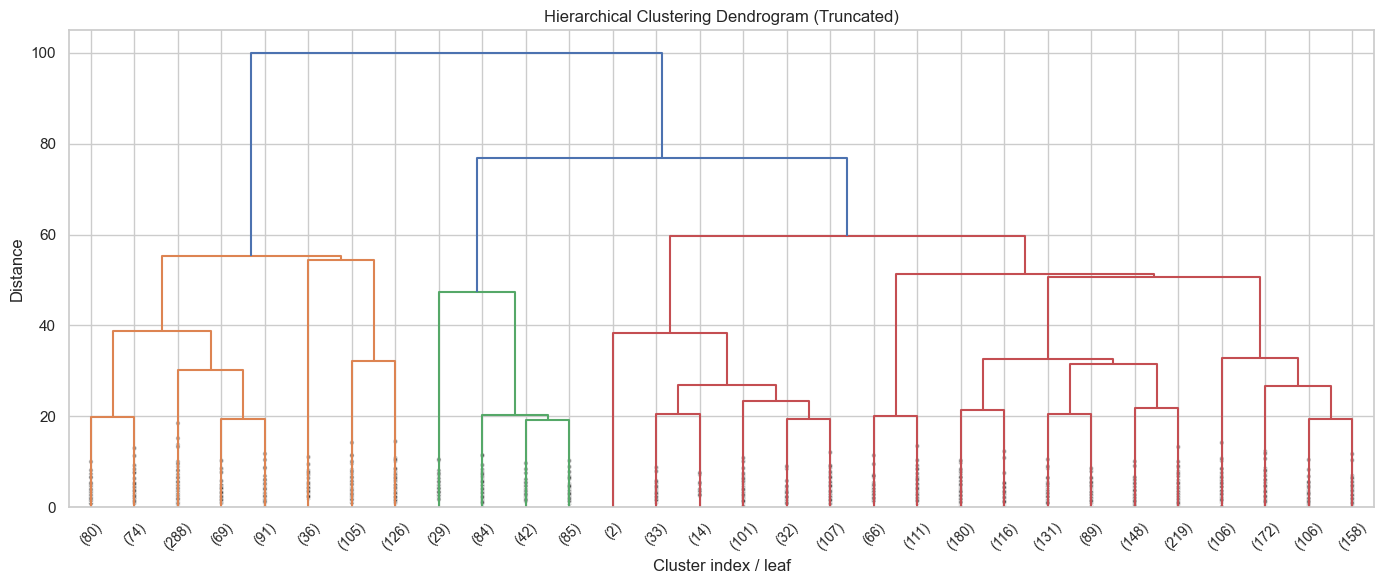

In [17]:
# Build linkage matrix for dendrogram.
Z = linkage(X_h, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster index / leaf')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [18]:
# Use the same k as K-Means for direct comparison.
h_k = int(best_k)
agg = AgglomerativeClustering(n_clusters=h_k, linkage='ward')
h_labels = agg.fit_predict(X_h)

df_h['hier_cluster'] = h_labels
h_silhouette = silhouette_score(X_h, h_labels)

print('Hierarchical clusters:', h_k)
print('Hierarchical silhouette:', round(h_silhouette, 4))
print('Cluster counts:')
print(df_h['hier_cluster'].value_counts().sort_index())

Hierarchical clusters: 3
Hierarchical silhouette: 0.1553
Cluster counts:
hier_cluster
0    1891
1     869
2     240
Name: count, dtype: int64


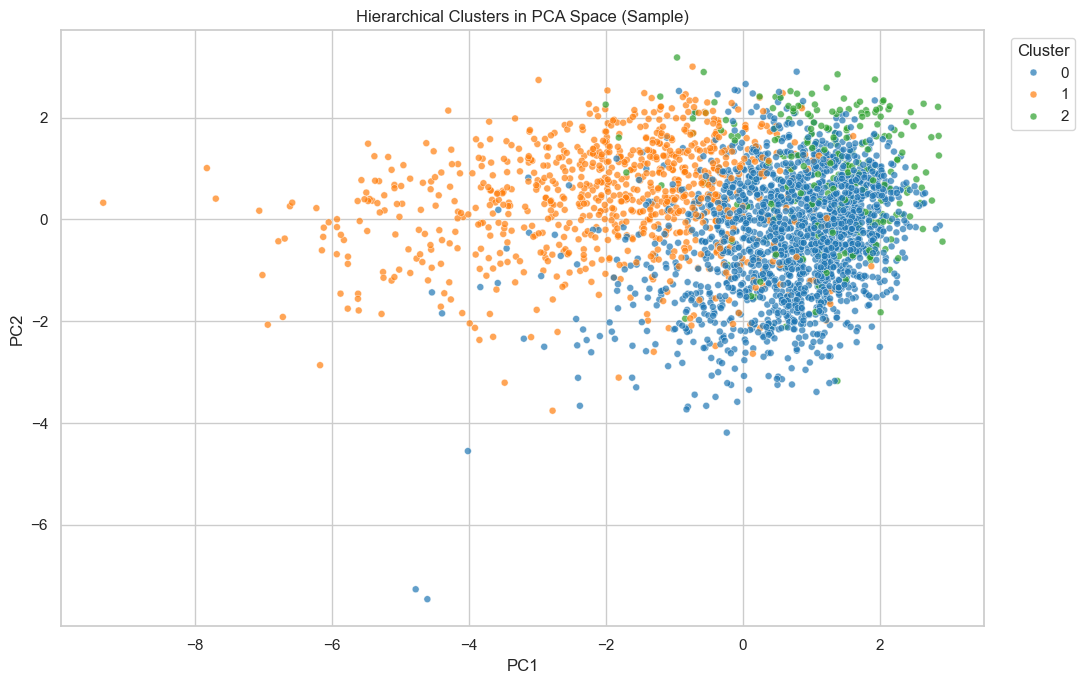

In [19]:
# PCA projection for hierarchical clusters (on sampled rows).
pca_h = PCA(n_components=2, random_state=42)
X_h_pca = pca_h.fit_transform(X_h)

plt.figure(figsize=(11, 7))
sns.scatterplot(x=X_h_pca[:, 0], y=X_h_pca[:, 1], hue=df_h['hier_cluster'],
                palette='tab10', s=25, alpha=0.7)
plt.title('Hierarchical Clusters in PCA Space (Sample)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
# Hierarchical cluster profile (sample only).
h_profile = pd.concat([pd.DataFrame(X_h, columns=features), df_h['hier_cluster'].reset_index(drop=True)], axis=1)
h_profile = h_profile.groupby('hier_cluster')[features].mean().round(3)
h_profile

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
hier_cluster,,,,,,,,,,,,,,,
0,0.023,0.111,-0.306,0.126,0.449,0.021,0.331,-0.004,-0.057,-0.454,-0.107,0.068,0.195,0.162,0.201
1,-0.129,-0.114,-0.306,-0.409,-1.108,-0.078,-0.854,0.073,-0.307,1.058,0.273,-0.315,-0.387,-0.319,-0.525
2,0.130,-0.219,3.070,0.436,0.266,-0.073,0.340,-0.042,1.329,-0.187,-0.435,0.320,0.055,0.003,0.226


## 8. Summary

In [21]:
print('=' * 70)
print('SPOTIFY TRACKS CLUSTERING SUMMARY')
print('=' * 70)
print(f'Total cleaned rows                  : {len(df_clustered)}')
print(f'Features used for clustering        : {len(features)}')
print(f'Best K-Means k (silhouette tuning)  : {best_k}')
print(f'K-Means silhouette (subset)         : {kmeans_silhouette:.4f}')
print(f'Hierarchical silhouette (sample)    : {h_silhouette:.4f}')
print('')
print('Notes:')
print('- K-Means was fit on full scaled data.')
print('- Hierarchical clustering used a sample for runtime and memory efficiency.')
print('- Use cluster profiles above to interpret listening-pattern segments.')
print('=' * 70)

SPOTIFY TRACKS CLUSTERING SUMMARY
Total cleaned rows                  : 89741
Features used for clustering        : 15
Best K-Means k (silhouette tuning)  : 3
K-Means silhouette (subset)         : 0.1972
Hierarchical silhouette (sample)    : 0.1553

Notes:
- K-Means was fit on full scaled data.
- Hierarchical clustering used a sample for runtime and memory efficiency.
- Use cluster profiles above to interpret listening-pattern segments.
